In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

np.random.seed(0)


def solve_lv(prey0, predator0, total_time, dt, parameters):
    """Solve the Lotka-Volterra system for the given initial values."""
    n_steps = int(total_time / dt)

    def lv_equations(t, state, a, b, c, d):
        prey, predator = state
        dprey_dt = a * prey - b * prey * predator
        dpredator_dt = c * prey * predator - d * predator
        return [dprey_dt, dpredator_dt]

    time_points = np.linspace(0, total_time, n_steps + 1)
    solution = solve_ivp(
        lv_equations,
        [0, total_time],
        [prey0, predator0],
        args=parameters,
        method="BDF",
        t_eval=time_points,
    )

    return solution.y[0], solution.y[1], solution.t


(20001,)


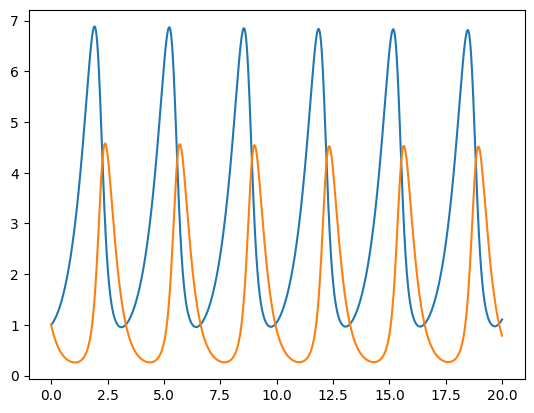

In [2]:
# Initial conditions and model parameters
prey_initial = 1
predator_initial = 1

parameters = [1.5, 1, 1, 3]
dt = 1e-3
T = 20

x1, x2, t = solve_lv(prey_initial, predator_initial, T, dt, parameters)
print(x1.shape)

plt.plot(t, x1)
plt.plot(t, x2)
# plt.show()
plt.savefig("data.png")

# np.save("data/x1.npy", x1)
# np.save("data/x2.npy", x2)
# np.save("data/time.npy", t)


In [154]:
# Draw noisy observations from the first part of each trajectory
num_data = 300
noise_percent = 0.1

x1_noise_std = noise_percent * np.mean(x1)
x2_noise_std = noise_percent * np.mean(x2)

x1_noise = np.random.normal(0, x1_noise_std, num_data)
x2_noise = np.random.normal(0, x2_noise_std, num_data)

sample_indices = np.random.randint(0, len(x1[:8001]), size=num_data)
sample_indices = np.sort(sample_indices)

x1_train = x1[sample_indices] + x1_noise
x2_train = x2[sample_indices] + x2_noise
t_train = t[sample_indices]


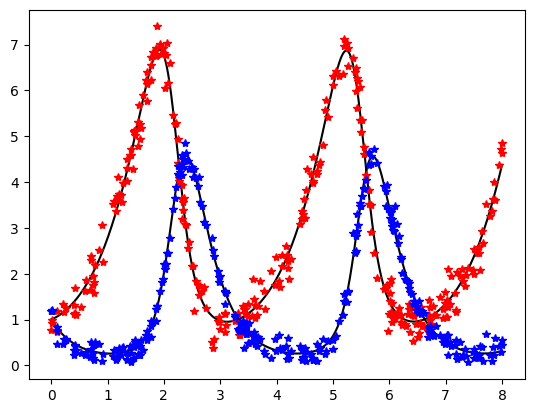

In [155]:
plt.plot(t[:8001], x1[:8001], "-k")
plt.plot(t[:8001], x2[:8001], "-k")
plt.plot(t_train, x1_train, "*r", label="x1 data")
plt.plot(t_train, x2_train, "*b", label="x2 data")
# plt.show()
plt.savefig("data.png")


In [156]:
import GPy

print(t_train.shape)
train_times = t_train[:, None]

# GP fit for the prey trajectory
x1_kernel = GPy.kern.RBF(input_dim=1, variance=1, lengthscale=1)
x1_model = GPy.models.GPRegression(train_times, x1_train[:, None], x1_kernel)
if noise_percent == 0:
    x1_model.Gaussian_noise.variance.fix(1e-6)
x1_model.optimize_restarts(num_restarts=2, verbose=True)
x1_smoothed, _ = x1_model.predict(train_times)

# GP fit for the predator trajectory
x2_kernel = GPy.kern.RBF(input_dim=1, variance=1, lengthscale=1)
x2_model = GPy.models.GPRegression(train_times, x2_train[:, None], x2_kernel)
if noise_percent == 0:
    x2_model.Gaussian_noise.variance.fix(1e-10)
x2_model.optimize_restarts(num_restarts=2, verbose=True)
x2_smoothed, _ = x2_model.predict(train_times)


(300,)
Optimization restart 1/2, f = 112.79249386058501
Optimization restart 2/2, f = 112.79249385723091
Optimization restart 1/2, f = -70.65685092130519
Optimization restart 2/2, f = -70.65685092482883


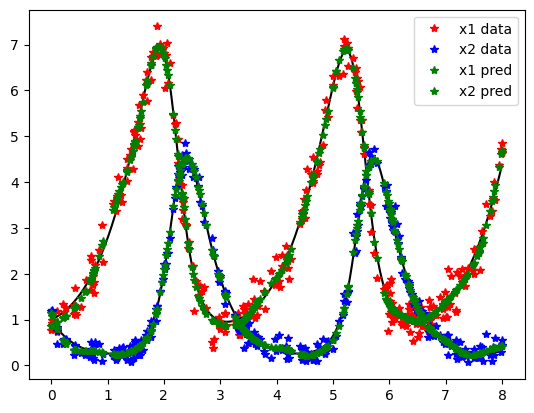

In [157]:
plt.plot(t[:8001], x1[:8001], "-k")
plt.plot(t[:8001], x2[:8001], "-k")
plt.plot(t_train, x1_train, "*r", label="x1 data")
plt.plot(t_train, x2_train, "*b", label="x2 data")
plt.plot(t_train, x1_smoothed, "*g", label="x1 pred")
plt.plot(t_train, x2_smoothed, "*g", label="x2 pred")
plt.legend()

# plt.show()


In [158]:
# Covariance matrices for x1 and its derivative
Kuu_x1 = x1_kernel.K(train_times)
Kdd_x1 = x1_kernel.dK2_dXdX2(train_times, train_times, 0, 0)

if noise_percent != 0:
    noise_variance = x1_model["Gaussian_noise"][0][0]
    Kuu_x1 = Kuu_x1 + np.identity(len(t_train)) * noise_variance
    Kdd_x1 = Kdd_x1 + np.identity(len(t_train)) * noise_variance

Kdu_x1 = x1_kernel.dK_dX(train_times, train_times, 0)
Kud_x1 = Kdu_x1.T

Kuu_inverse = np.linalg.inv(Kuu_x1)
Rdd_x1 = np.linalg.inv(Kdd_x1 - Kdu_x1 @ Kuu_inverse @ Kud_x1)
Rdu_x1 = -Rdd_x1 @ Kdu_x1 @ Kuu_inverse

# Estimate the two coefficients in dx1/dt = theta_1*x1 + theta_2*x1*x2
feature_matrix = np.hstack((x1_smoothed, x1_smoothed * x2_smoothed))
weighted_features = feature_matrix.T @ Rdd_x1 @ feature_matrix
theta_x1 = -np.linalg.inv(weighted_features) @ feature_matrix.T @ Rdu_x1 @ x1_train[:, None]
theta_cov_x1 = np.linalg.inv(weighted_features)

print(theta_x1, theta_cov_x1)


[[ 1.48131941]
 [-1.00333275]] [[ 2.50520533e-04 -1.40929443e-04]
 [-1.40929443e-04  9.38017692e-05]]
